# Event Correlation & Root Cause Analysis

## Projeto de Machine Learning para Correlação de Eventos e RCA

Este projeto desenvolve um protótipo de Root Cause Analysis (RCA)
para ambientes distribuídos.

O objetivo é identificar possíveis causas-raiz a partir de eventos
operacionais observados ao longo do tempo.

### Técnicas utilizadas

- Correlação temporal
- Coocorrência de eventos
- Feature Engineering
- Aprendizado supervisionado
- Ranking Top-K
- Inferência causal

Etapa 1 — Projeto e GitHub

criar repositório;
criar ambiente Python;
instalar bibliotecas;
criar estrutura.

Etapa 2 — Dados

gerar eventos distribuídos sintéticos;
criar causas verdadeiras;
criar dependências entre eventos.

Etapa 3 — Correlação

coocorrência;
janela temporal;
recorrência;
severidade;
dependência entre sistemas/agências.

Etapa 4 — Machine Learning

preparar X e y;
Random Forest;
probabilidades;
Top-1 / Top-3.

Etapa 5 — RCA

ranking das causas;
explicação das features;
análise dos erros.

Etapa 6 — Inferência causal

DAG;
confundidores;
correlação versus causalidade;
uma análise causal simples.

Etapa 7 — README

problema;
metodologia;
arquitetura;
resultados;
limitações;
próximos passos.

"Desenvolvi um protótipo de correlação de eventos distribuídos e Root Cause Analysis utilizando engenharia de atributos temporais, modelos supervisionados, ranking Top-K e uma camada de análise causal."

In [1]:
import pandas as pd
import numpy as np

from datetime import datetime, timedelta
from IPython.display import display

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, top_k_accuracy_score

np.random.seed(42)

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


#Conjunto de Eventos

In [2]:
# Configurações do dataset

n_incidentes = 500

agencias = [
    "AGENCIA_RJ_01",
    "AGENCIA_RJ_02",
    "AGENCIA_SP_01",
    "AGENCIA_SP_02",
    "AGENCIA_MG_01"
]

sistemas = [
    "API",
    "DATABASE",
    "PAYMENT",
    "AUTH",
    "CACHE",
    "NETWORK"
]

causas_raiz = [
    "DB_FAILURE",
    "NETWORK_FAILURE",
    "API_FAILURE",
    "AUTH_FAILURE",
    "CACHE_FAILURE"
]

severidades = [
    "LOW",
    "MEDIUM",
    "HIGH",
    "CRITICAL"
]

print("Agências:", len(agencias))
print("Sistemas:", len(sistemas))
print("Causas-raiz:", len(causas_raiz))

Agências: 5
Sistemas: 6
Causas-raiz: 5


#**Incidentes**

In [3]:
incidentes = []

data_inicial = datetime(2026, 1, 1)

for incident_id in range(1, n_incidentes + 1):

    agencia = np.random.choice(agencias)
    causa_raiz = np.random.choice(causas_raiz)

    timestamp_inicio = data_inicial + timedelta(
        minutes=np.random.randint(0, 60 * 24 * 90)
    )

    severidade = np.random.choice(
        severidades,
        p=[0.20, 0.35, 0.30, 0.15]
    )

    incidentes.append({
        "incident_id": incident_id,
        "agencia": agencia,
        "timestamp_inicio": timestamp_inicio,
        "causa_raiz": causa_raiz,
        "severidade": severidade
    })

df_incidentes = pd.DataFrame(incidentes)

df_incidentes.head()

,incident_id,agencia,timestamp_inicio,causa_raiz,severidade
0,1,AGENCIA_SP_02,2026-03-14 00:14:00,CACHE_FAILURE,HIGH
1,2,AGENCIA_MG_01,2026-02-08 02:46:00,CACHE_FAILURE,MEDIUM
2,3,AGENCIA_SP_01,2026-03-20 06:47:00,API_FAILURE,MEDIUM
3,4,AGENCIA_SP_01,2026-01-01 12:49:00,CACHE_FAILURE,HIGH
4,5,AGENCIA_RJ_02,2026-03-14 17:24:00,AUTH_FAILURE,HIGH


EU:

Temos 500 incidentes simulados.

Cada incidente possui uma causa-raiz conhecida.

Isso é proposital.

No treinamento supervisionado, essa coluna:

causa_raiz

será nosso target (y).

Mais tarde vamos esconder essa informação do modelo e perguntar:

"Dado o comportamento dos eventos, qual é a causa-raiz?"

In [4]:
# Padrões de eventos associados a cada causa-raiz

padroes_eventos = {

    "DB_FAILURE": [
        ("DATABASE", "DB_CONNECTION_ERROR"),
        ("API", "API_TIMEOUT"),
        ("PAYMENT", "PAYMENT_FAILURE")
    ],

    "NETWORK_FAILURE": [
        ("NETWORK", "NETWORK_LATENCY"),
        ("API", "API_TIMEOUT"),
        ("PAYMENT", "PAYMENT_FAILURE")
    ],

    "API_FAILURE": [
        ("API", "API_ERROR"),
        ("PAYMENT", "PAYMENT_FAILURE"),
        ("API", "API_TIMEOUT")
    ],

    "AUTH_FAILURE": [
        ("AUTH", "AUTH_ERROR"),
        ("API", "API_AUTH_FAILURE"),
        ("PAYMENT", "PAYMENT_FAILURE")
    ],

    "CACHE_FAILURE": [
        ("CACHE", "CACHE_ERROR"),
        ("API", "API_SLOW_RESPONSE"),
        ("PAYMENT", "PAYMENT_FAILURE")
    ]
}

padroes_eventos

{'DB_FAILURE': [('DATABASE', 'DB_CONNECTION_ERROR'),
  ('API', 'API_TIMEOUT'),
  ('PAYMENT', 'PAYMENT_FAILURE')],
 'NETWORK_FAILURE': [('NETWORK', 'NETWORK_LATENCY'),
  ('API', 'API_TIMEOUT'),
  ('PAYMENT', 'PAYMENT_FAILURE')],
 'API_FAILURE': [('API', 'API_ERROR'),
  ('PAYMENT', 'PAYMENT_FAILURE'),
  ('API', 'API_TIMEOUT')],
 'AUTH_FAILURE': [('AUTH', 'AUTH_ERROR'),
  ('API', 'API_AUTH_FAILURE'),
  ('PAYMENT', 'PAYMENT_FAILURE')],
 'CACHE_FAILURE': [('CACHE', 'CACHE_ERROR'),
  ('API', 'API_SLOW_RESPONSE'),
  ('PAYMENT', 'PAYMENT_FAILURE')]}

#EVENTOS

In [5]:
eventos = []

for _, incidente in df_incidentes.iterrows():

    incident_id = incidente["incident_id"]
    agencia = incidente["agencia"]
    causa_raiz = incidente["causa_raiz"]
    timestamp_inicio = incidente["timestamp_inicio"]

    eventos_causa = padroes_eventos[causa_raiz]

    for ordem, (sistema, tipo_evento) in enumerate(eventos_causa):

        # Pequeno intervalo entre os eventos
        timestamp_evento = timestamp_inicio + timedelta(
            minutes=ordem * np.random.randint(1, 6)
        )

        # Severidade aumenta ou se mantém ao longo da cadeia
        severidade = np.random.choice(
            ["LOW", "MEDIUM", "HIGH", "CRITICAL"],
            p=[0.10, 0.30, 0.40, 0.20]
        )

        eventos.append({
            "incident_id": incident_id,
            "agencia": agencia,
            "timestamp": timestamp_evento,
            "sistema": sistema,
            "evento": tipo_evento,
            "severidade": severidade,
            "ordem_evento": ordem + 1,
            "causa_raiz": causa_raiz
        })

df_eventos = pd.DataFrame(eventos)

df_eventos.head(15)

,incident_id,agencia,timestamp,sistema,evento,severidade,ordem_evento,causa_raiz
0,1,AGENCIA_SP_02,2026-03-14 00:14:00,CACHE,CACHE_ERROR,MEDIUM,1,CACHE_FAILURE
1,1,AGENCIA_SP_02,2026-03-14 00:18:00,API,API_SLOW_RESPONSE,HIGH,2,CACHE_FAILURE
2,1,AGENCIA_SP_02,2026-03-14 00:24:00,PAYMENT,PAYMENT_FAILURE,CRITICAL,3,CACHE_FAILURE
3,2,AGENCIA_MG_01,2026-02-08 02:46:00,CACHE,CACHE_ERROR,HIGH,1,CACHE_FAILURE
4,2,AGENCIA_MG_01,2026-02-08 02:48:00,API,API_SLOW_RESPONSE,HIGH,2,CACHE_FAILURE
5,2,AGENCIA_MG_01,2026-02-08 02:50:00,PAYMENT,PAYMENT_FAILURE,MEDIUM,3,CACHE_FAILURE
6,3,AGENCIA_SP_01,2026-03-20 06:47:00,API,API_ERROR,HIGH,1,API_FAILURE
7,3,AGENCIA_SP_01,2026-03-20 06:48:00,PAYMENT,PAYMENT_FAILURE,HIGH,2,API_FAILURE
8,3,AGENCIA_SP_01,2026-03-20 06:55:00,API,API_TIMEOUT,MEDIUM,3,API_FAILURE
9,4,AGENCIA_SP_01,2026-01-01 12:49:00,CACHE,CACHE_ERROR,MEDIUM,1,CACHE_FAILURE


In [6]:
print("Número de incidentes:", df_incidentes.shape[0])
print("Número de eventos:", df_eventos.shape[0])
print("Número de colunas:", df_eventos.shape[1])

Número de incidentes: 500
Número de eventos: 1500
Número de colunas: 8


#Etapa 6 — análise exploratória dos eventos

6.1 — Quantidade de cada causa-raiz

In [7]:
df_incidentes["causa_raiz"].value_counts()

causa_raiz
AUTH_FAILURE       110
CACHE_FAILURE      107
API_FAILURE        105
NETWORK_FAILURE     91
DB_FAILURE          87
Name: count, dtype: int64

6.2 — Visualizar as causas

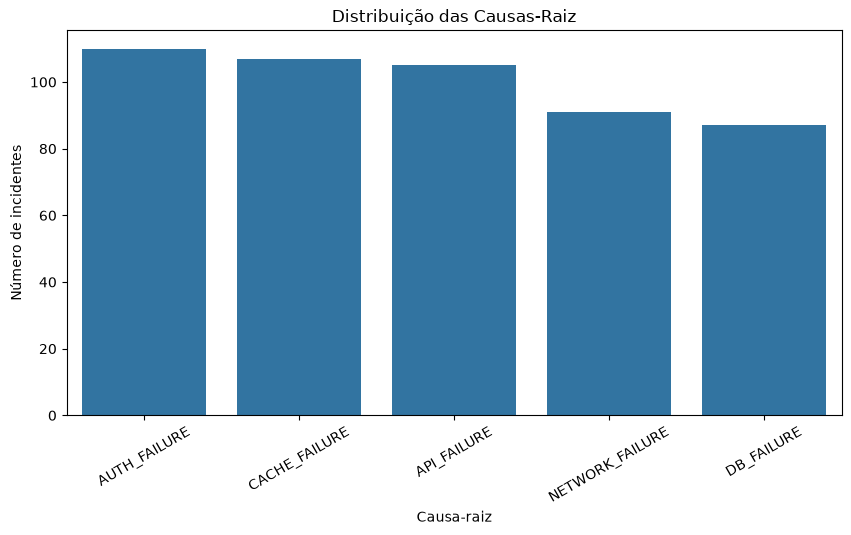

In [8]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df_incidentes,
    x="causa_raiz",
    order=df_incidentes["causa_raiz"].value_counts().index
)

plt.title("Distribuição das Causas-Raiz")
plt.xlabel("Causa-raiz")
plt.ylabel("Número de incidentes")
plt.xticks(rotation=30)

plt.show()

6.3 — Ver os eventos mais frequentes

In [9]:
df_eventos["evento"].value_counts()

evento
PAYMENT_FAILURE        500
API_TIMEOUT            283
AUTH_ERROR             110
API_AUTH_FAILURE       110
CACHE_ERROR            107
API_SLOW_RESPONSE      107
API_ERROR              105
NETWORK_LATENCY         91
DB_CONNECTION_ERROR     87
Name: count, dtype: int64

Isso significa que ele é um evento comum, mas provavelmente não é uma boa indicação de causa-raiz.

Esse é exatamente o tipo de problema que o nosso sistema de RCA precisa resolver.

6.4 — Uma visualização importante

Vamos agora olhar para a relação entre causa-raiz e evento:

In [10]:
tabela_eventos = pd.crosstab(
    df_eventos["causa_raiz"],
    df_eventos["evento"]
)

tabela_eventos

evento,API_AUTH_FAILURE,API_ERROR,API_SLOW_RESPONSE,API_TIMEOUT,AUTH_ERROR,CACHE_ERROR,DB_CONNECTION_ERROR,NETWORK_LATENCY,PAYMENT_FAILURE
causa_raiz,,,,,,,,,
API_FAILURE,0,105,0,105,0,0,0,0,105
AUTH_FAILURE,110,0,0,0,110,0,0,0,110
CACHE_FAILURE,0,0,107,0,0,107,0,0,107
DB_FAILURE,0,0,0,87,0,0,87,0,87
NETWORK_FAILURE,0,0,0,91,0,0,0,91,91


                 EVENTOS
                    ↓
        ┌───────────┴───────────┐
        ↓                       ↓
   DB_FAILURE             NETWORK_FAILURE
        ↓                       ↓
DB_CONNECTION_ERROR      NETWORK_LATENCY
        ↓                       ↓
   API_TIMEOUT             API_TIMEOUT
        └───────────┬───────────┘
                    ↓
             PAYMENT_FAILURE

O evento PAYMENT_FAILURE sozinho não identifica a causa.

Mas a combinação dos eventos + ordem + tempo + sistema pode identificar.

É aí que entra o nosso feature engineering.

Próximo passo

Depois dessa análise, vamos começar a construir as features que aparecem explicitamente na vaga:

1. Coocorrência
2. Janela temporal
3. Dependência entre sistemas
4. Recorrência
5. Severidade

E vamos transformar tudo isso em uma matriz:

X = features dos incidentes

y = causa_raiz

Etapa 7 — Feature Engineering

In [11]:
# ==========================================
# FEATURE ENGINEERING
# ==========================================

# 1. Presença de cada tipo de evento
X = pd.crosstab(
    df_eventos["incident_id"],
    df_eventos["evento"]
)

# 2. Janela temporal do incidente
janela = df_eventos.groupby("incident_id")["timestamp"].agg(
    lambda x: (x.max() - x.min()).total_seconds() / 60
)

X["janela_temporal_min"] = janela

# 3. Severidade máxima
mapa_severidade = {
    "LOW": 1,
    "MEDIUM": 2,
    "HIGH": 3,
    "CRITICAL": 4
}

df_eventos["severidade_num"] = df_eventos["severidade"].map(mapa_severidade)

X["severidade_max"] = (
    df_eventos
    .groupby("incident_id")["severidade_num"]
    .max()
)

X.head()

evento,API_AUTH_FAILURE,API_ERROR,API_SLOW_RESPONSE,API_TIMEOUT,AUTH_ERROR,CACHE_ERROR,DB_CONNECTION_ERROR,NETWORK_LATENCY,PAYMENT_FAILURE,janela_temporal_min,severidade_max
incident_id,,,,,,,,,,,
1,0,0,1,0,0,1,0,0,1,10.0,4
2,0,0,1,0,0,1,0,0,1,4.0,3
3,0,1,0,1,0,0,0,0,1,8.0,3
4,0,0,1,0,0,1,0,0,1,4.0,4
5,1,0,0,0,1,0,0,0,1,10.0,3


Etapa 8 — Random Forest

8.1 — Criar o target

In [12]:
# ==========================================
# TARGET - CAUSA RAIZ
# ==========================================

y = (
    df_incidentes
    .set_index("incident_id")
    .loc[X.index, "causa_raiz"]
)

print("X:", X.shape)
print("y:", y.shape)

y.head()

X: (500, 11)
y: (500,)


incident_id
1    CACHE_FAILURE
2    CACHE_FAILURE
3      API_FAILURE
4    CACHE_FAILURE
5     AUTH_FAILURE
Name: causa_raiz, dtype: str

8.2 — Separar treino e teste

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (400, 11)
Teste: (100, 11)


8.3 — Treinar Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

modelo.fit(X_train, y_train)

print("Modelo treinado!")

Modelo treinado!


8.4 — Fazer previsões

In [15]:
y_pred = modelo.predict(X_test)
probas = modelo.predict_proba(X_test)
classes = modelo.classes_

acuracia = accuracy_score(y_test, y_pred)
acuracia_top3 = top_k_accuracy_score(
    y_test,
    probas,
    k=3,
    labels=classes
)

print(f"Acurácia Top-1: {acuracia:.2%}")
print(f"Acurácia Top-3: {acuracia_top3:.2%}")

Acurácia Top-1: 100.00%
Acurácia Top-3: 100.00%


9. Top-1 e Top-3 — uma única célula

In [16]:
# ==========================================
# TOP-1 E TOP-3 CAUSAS PROVÁVEIS
# ==========================================

probas = modelo.predict_proba(X_test)
classes = modelo.classes_

# Exemplo: primeiro incidente do conjunto de teste
i = 0

ranking = pd.DataFrame({
    "causa_raiz": classes,
    "probabilidade": probas[i]
}).sort_values(
    "probabilidade",
    ascending=False
)

print("Causa real:", y_test.iloc[i])

print("\nTOP-1:")
display(ranking.head(1))

print("\nTOP-3:")
display(ranking.head(3))

Causa real: API_FAILURE

TOP-1:


,causa_raiz,probabilidade
0,API_FAILURE,1.0



TOP-3:


,causa_raiz,probabilidade
0,API_FAILURE,1.0
1,AUTH_FAILURE,0.0
2,CACHE_FAILURE,0.0


## Conclusão

Este projeto apresenta um protótipo de correlação de eventos e Root Cause Analysis (RCA) em um ambiente distribuído simulado.

O fluxo demonstra:

- geração de incidentes e eventos sintéticos;
- coocorrência de eventos;
- engenharia de atributos temporais e de severidade;
- classificação supervisionada com Random Forest;
- ranking de possíveis causas-raiz com Top-1 e Top-3.

As métricas são calculadas durante a execução do notebook. Como os padrões sintéticos possuem forte separação entre as classes, o resultado não deve ser interpretado como desempenho esperado em produção.

Em um ambiente real, eventos apresentam ruído, sobreposição, dados ausentes e dependências complexas. Próximos passos incluem adicionar recorrência, dependências entre serviços, validação temporal, dados reais anonimizados e métodos formais de inferência causal.